#Data Overview

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'data/stroke_prediction_dataset.csv'
df = pd.read_csv(file_path)

print("Stroke Prediction Dataset")

print(f"\nDataset Size:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print(f"\nData Quality Check:")
print(f"Missing Values:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0].to_frame(name='Missing Count'))
if missing_data.sum() == 0:
    print("No missing values found!")
print(f"Duplicates found: {df.duplicated().sum()}")

print("\nColumns and their Data Types:")
print(df.dtypes.to_string())

print("\n5 Earliest Row")
df.head()

Stroke Prediction Dataset

Dataset Size:
Rows: 15000
Columns: 22

Data Quality Check:
Missing Values:
          Missing Count
Symptoms           2500
Duplicates found: 0

Columns and their Data Types:
Patient ID                    int64
Patient Name                    str
Age                           int64
Gender                          str
Hypertension                  int64
Heart Disease                 int64
Marital Status                  str
Work Type                       str
Residence Type                  str
Average Glucose Level       float64
Body Mass Index (BMI)       float64
Smoking Status                  str
Alcohol Intake                  str
Physical Activity               str
Stroke History                int64
Family History of Stroke        str
Dietary Habits                  str
Stress Levels               float64
Blood Pressure Levels           str
Cholesterol Levels              str
Symptoms                        str
Diagnosis                       str

5 Earl

,Patient ID,Patient Name,Age,Gender,Hypertension,Heart Disease,Marital Status,Work Type,Residence Type,Average Glucose Level,...,Alcohol Intake,Physical Activity,Stroke History,Family History of Stroke,Dietary Habits,Stress Levels,Blood Pressure Levels,Cholesterol Levels,Symptoms,Diagnosis
0,18153,Mamooty Khurana,56,Male,0,1,Married,Self-employed,Rural,130.91,...,Social Drinker,Moderate,0,Yes,Vegan,3.48,140/108,"HDL: 68, LDL: 133","Difficulty Speaking, Headache",Stroke
1,62749,Kaira Subramaniam,80,Male,0,0,Single,Self-employed,Urban,183.73,...,Never,Low,0,No,Paleo,1.73,146/91,"HDL: 63, LDL: 70","Loss of Balance, Headache, Dizziness, Confusion",Stroke
2,32145,Dhanush Balan,26,Male,1,1,Married,Never Worked,Rural,189.00,...,Rarely,High,0,Yes,Paleo,7.31,154/97,"HDL: 59, LDL: 95","Seizures, Dizziness",Stroke
3,6154,Ivana Baral,73,Male,0,0,Married,Never Worked,Urban,185.29,...,Frequent Drinker,Moderate,0,No,Paleo,5.35,174/81,"HDL: 70, LDL: 137","Seizures, Blurred Vision, Severe Fatigue, Head...",No Stroke
4,48973,Darshit Jayaraman,51,Male,1,1,Divorced,Self-employed,Urban,177.34,...,Rarely,Low,0,Yes,Pescatarian,6.84,121/95,"HDL: 65, LDL: 68",Difficulty Speaking,Stroke


##Data Diagrams

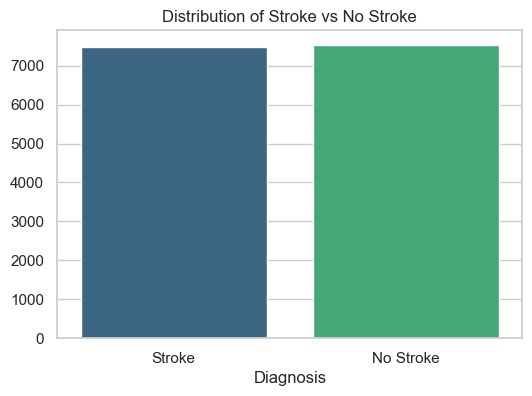

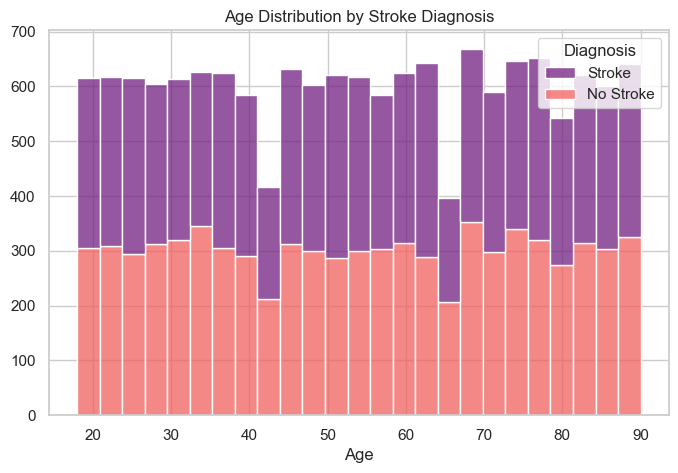

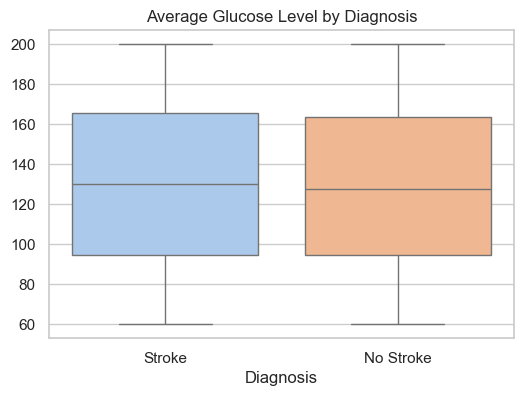

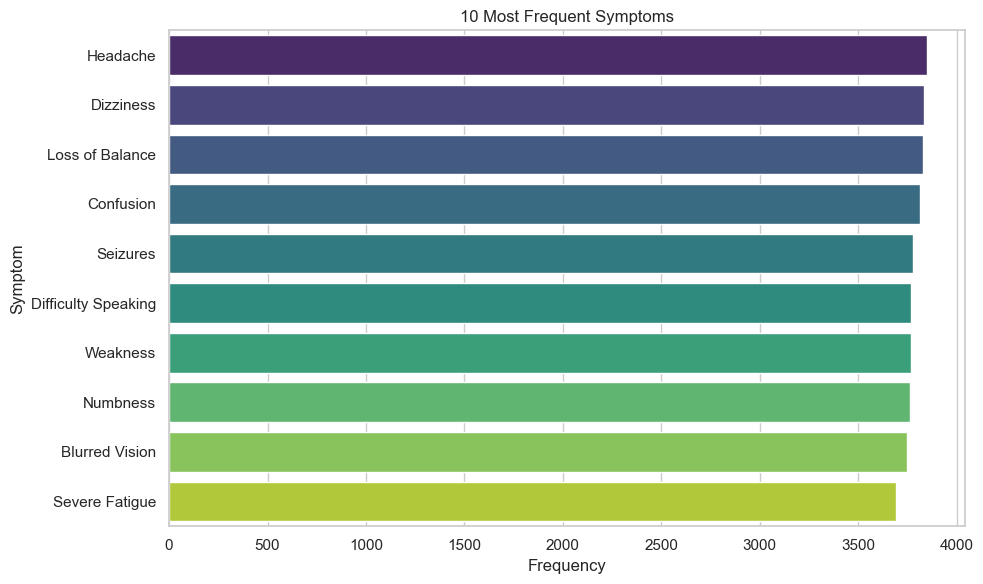

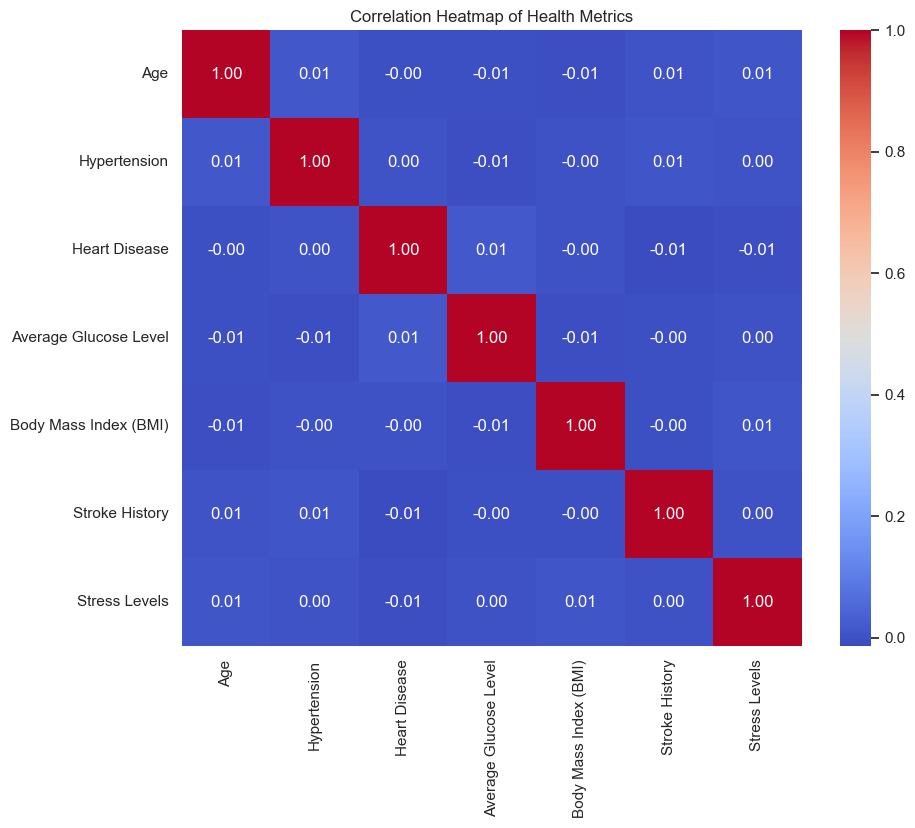

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'data/stroke_prediction_dataset.csv'
df = pd.read_csv(file_path)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Diagnosis', hue='Diagnosis', palette='viridis', legend=False)
plt.ylabel(None)
plt.title('Distribution of Stroke vs No Stroke')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Diagnosis', multiple="stack", palette='magma')
plt.ylabel(None)
plt.title('Age Distribution by Stroke Diagnosis')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Diagnosis', y='Average Glucose Level', hue='Diagnosis', palette='pastel', legend=False)
plt.ylabel(None)
plt.title('Average Glucose Level by Diagnosis')
plt.show()

symptom_counts = (
    df['Symptoms']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=symptom_counts.values, y=symptom_counts.index, hue=symptom_counts.index, palette='viridis', legend=False)
plt.title('10 Most Frequent Symptoms')
plt.xlabel('Frequency')
plt.ylabel('Symptom')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,8))
numerical_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['Patient ID'])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Health Metrics')
plt.show()